# Ganga River Water Quality Classification using Decision Tree

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## 1. Load Data
Load the raw water quality monitoring dataset from `Datasets/stations_full.csv`.

In [31]:
# --- 1. Load Data ---
df = pd.read_csv('Datasets/cleaned_stations.csv', skiprows=[1])
print(f'Dataset Shape: {df.shape}')
df.head()

Dataset Shape: (1425, 36)


,state_name,temp_min,temp_max,do_min,do_max,ph_min,ph_max,conductivity_min,conductivity_max,bod_min,...,conductivity_avg,bod_range,bod_avg,nitrate_range,nitrate_avg,fecal_coliform_range,fecal_coliform_avg,total_coliform_range,total_coliform_avg,wqi_category
0,31.0,2.0,13.0,7.6,9.0,6.5,8.1,58.0,135.0,1.0,...,96.5,1.8,1.9,1.55,1.095,1490.0,855.0,680.0,1260.0,Poor
1,31.0,2.0,13.0,7.8,8.8,6.7,7.8,62.0,113.0,1.0,...,87.5,1.8,1.9,0.76,0.700,1490.0,855.0,1250.0,975.0,Poor
2,31.0,2.0,14.0,7.9,8.9,6.3,8.0,52.0,137.0,1.0,...,94.5,0.0,1.0,1.42,1.030,88.0,66.0,461.0,309.5,Poor
3,31.0,2.0,13.0,7.8,9.1,7.0,7.8,51.0,113.0,1.0,...,82.0,0.0,1.0,0.65,0.645,97.0,71.5,320.0,270.0,Poor
4,31.0,4.0,16.0,7.6,8.7,6.7,7.8,44.0,128.0,1.0,...,86.0,0.0,1.0,0.58,0.610,171.0,134.5,680.0,580.0,Poor


## 2. Data Overview
Inspect summary information, data types, and descriptive statistics.

In [32]:
# View DataFrame summary
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1425 entries, 0 to 1424
Data columns (total 36 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state_name              1425 non-null   float64
 1   temp_min                1425 non-null   float64
 2   temp_max                1425 non-null   float64
 3   do_min                  1425 non-null   float64
 4   do_max                  1425 non-null   float64
 5   ph_min                  1425 non-null   float64
 6   ph_max                  1425 non-null   float64
 7   conductivity_min        1425 non-null   float64
 8   conductivity_max        1425 non-null   float64
 9   bod_min                 1425 non-null   float64
 10  bod_max                 1425 non-null   float64
 11  nitrate_min             1425 non-null   float64
 12  nitrate_max             1425 non-null   float64
 13  fecal_coliform_min      1425 non-null   float64
 14  fecal_coliform_max      1425 non-null   float64
 15

In [33]:
# View numerical column statistics
df.describe()

,state_name,temp_min,temp_max,do_min,do_max,ph_min,ph_max,conductivity_min,conductivity_max,bod_min,...,conductivity_range,conductivity_avg,bod_range,bod_avg,nitrate_range,nitrate_avg,fecal_coliform_range,fecal_coliform_avg,total_coliform_range,total_coliform_avg
count,1425.000000,1425.000000,1425.000000,1425.000000,1425.000000,1425.000000,1425.000000,1425.000000,1425.000000,1425.000000,...,1425.000000,1425.000000,1425.000000,1425.000000,1.425000e+03,1.425000e+03,1.425000e+03,1.425000e+03,1.425000e+03,1.425000e+03
mean,53.369825,20.019228,27.318877,5.876912,7.913544,13.167944,21.911495,307.402175,1275.803509,2.612189,...,968.401333,791.602842,2.866400,4.045389,1.419247e+04,7.490358e+03,7.482804e+04,4.143025e+04,3.594050e+05,1.864064e+05
std,24.674227,55.831321,6.103040,2.090816,1.934334,45.110344,108.500027,948.670801,4357.774045,15.539747,...,4057.882007,2414.225313,18.054328,10.308135,3.861483e+05,1.947481e+05,9.099175e+05,4.649626e+05,5.280835e+06,2.650381e+06
min,0.000000,0.300000,2.400000,0.300000,0.300000,2.000000,3.000000,1.000000,1.600000,0.000000,...,-0.300000,1.300000,-571.000000,0.000000,-1.230000e+00,0.000000e+00,0.000000e+00,1.710000e+00,0.000000e+00,2.000000e+00
25%,31.000000,15.000000,24.000000,5.100000,7.000000,7.000000,7.900000,130.000000,272.000000,1.000000,...,104.000000,209.500000,0.500000,1.500000,3.400000e-01,5.600000e-01,1.900000e+01,1.850000e+01,1.100000e+02,1.160000e+02
50%,50.000000,19.500000,29.000000,6.200000,8.000000,7.200000,8.200000,214.000000,478.000000,1.200000,...,227.000000,350.000000,1.000000,2.000000,1.100000e+00,9.900000e-01,1.330000e+02,1.245000e+02,6.800000e+02,8.165000e+02
75%,79.000000,23.000000,31.000000,7.100000,9.000000,7.500000,8.400000,331.000000,873.000000,2.100000,...,488.000000,612.000000,2.000000,3.000000,2.750000e+00,2.080000e+00,1.900000e+03,1.400000e+03,4.410000e+03,3.100000e+03
max,88.000000,2115.000000,39.000000,25.000000,28.000000,755.000000,1878.000000,34400.000000,54200.000000,572.000000,...,47742.000000,44300.000000,143.600000,286.500000,1.399220e+07,7.003900e+06,2.399780e+07,1.200110e+07,1.599930e+08,8.000350e+07


## 3. Remove Unwanted Columns
Drop non-predictive identifier columns such as `station_code` and `monitoring_location`.

In [34]:
# --- 3. Check Columns ---
df.head()

,state_name,temp_min,temp_max,do_min,do_max,ph_min,ph_max,conductivity_min,conductivity_max,bod_min,...,conductivity_avg,bod_range,bod_avg,nitrate_range,nitrate_avg,fecal_coliform_range,fecal_coliform_avg,total_coliform_range,total_coliform_avg,wqi_category
0,31.0,2.0,13.0,7.6,9.0,6.5,8.1,58.0,135.0,1.0,...,96.5,1.8,1.9,1.55,1.095,1490.0,855.0,680.0,1260.0,Poor
1,31.0,2.0,13.0,7.8,8.8,6.7,7.8,62.0,113.0,1.0,...,87.5,1.8,1.9,0.76,0.700,1490.0,855.0,1250.0,975.0,Poor
2,31.0,2.0,14.0,7.9,8.9,6.3,8.0,52.0,137.0,1.0,...,94.5,0.0,1.0,1.42,1.030,88.0,66.0,461.0,309.5,Poor
3,31.0,2.0,13.0,7.8,9.1,7.0,7.8,51.0,113.0,1.0,...,82.0,0.0,1.0,0.65,0.645,97.0,71.5,320.0,270.0,Poor
4,31.0,4.0,16.0,7.6,8.7,6.7,7.8,44.0,128.0,1.0,...,86.0,0.0,1.0,0.58,0.610,171.0,134.5,680.0,580.0,Poor


## 4. Preprocessing & Target Variable Classification
Convert feature columns to numeric types and derive the target variable `wqi_category` using Dissolved Oxygen (`do_max`), Biological Oxygen Demand (`bod_max`), and Fecal Coliform (`fecal_coliform_max`).

In [35]:
# --- 4. Preprocessing & Feature Engineering ---
# Convert parameter columns to numeric
for col in df.columns:
    if col != 'state_name':
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows missing essential target classification parameters
target_features = ['do_max', 'bod_max', 'fecal_coliform_max']
df.dropna(subset=target_features, inplace=True)

# WQI Classification Logic
def classify_wqi(row):
    do_max = row['do_max']
    bod_max = row['bod_max']
    fecal_coliform_max = row['fecal_coliform_max']

    if do_max > 6.5 and bod_max < 2 and fecal_coliform_max < 100:
        return 'Good'
    elif 5 < do_max <= 6.5 and 2 <= bod_max < 5 and 100 <= fecal_coliform_max < 1000:
        return 'Moderate'
    else:
        return 'Poor'

df['wqi_category'] = df.apply(classify_wqi, axis=1)
print("Target variable 'wqi_category' distribution:")
print(df['wqi_category'].value_counts())

Target variable 'wqi_category' distribution:
wqi_category
Poor        1164
Good         213
Moderate      48
Name: count, dtype: int64


## 5. Handle Missing Values
Check missing value counts, fill missing numeric values with column mean averages, and apply `LabelEncoder` on `state_name`.

In [36]:
# --- 5. Handle Missing Values ---
features = [col for col in df.columns if ('_min' in col or '_max' in col)] + ['state_name']
X = df[features].copy()
y = df['wqi_category']

print(f'Total missing values before imputation: {X.isnull().sum().sum()}')

# Impute missing values for numerical columns using column mean
numeric_cols = X.select_dtypes(include=['number']).columns
for col in numeric_cols:
    X[col] = X[col].fillna(X[col].mean())

# Label Encode categorical column (state_name)
if 'state_name' in X.columns:
    le = LabelEncoder()
    X['state_name'] = le.fit_transform(X['state_name'].astype(str))

print(f'Total missing values remaining after imputation: {X.isnull().sum().sum()}')

Total missing values before imputation: 0
Total missing values remaining after imputation: 0


## 6. Feature Scaling & Range Normalization
Make all feature column values fall within a consistent range using `StandardScaler` (and `MinMaxScaler` for explicit [0, 1] range scaling) for standard pipeline normalization.

In [37]:
# --- 6. Feature Scaling (Range Normalization) ---
# 1. StandardScaler (Standardization: mean=0, std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. MinMaxScaler (Range Normalization: [0, 1])
minmax_scaler = MinMaxScaler(feature_range=(0, 1))
X_minmax = minmax_scaler.fit_transform(X)

print(f'Scaled feature matrix shape: {X_scaled.shape}')
print(f'MinMaxScaler feature range check - Min: {X_minmax.min():.1f}, Max: {X_minmax.max():.1f}')

Scaled feature matrix shape: (1425, 19)
MinMaxScaler feature range check - Min: 0.0, Max: 1.0


## 7. Train Decision Tree Model
Split the dataset (80% training, 20% testing) with stratification and train the `DecisionTreeClassifier` with hyperparameters (`max_depth=5, max_features=3, random_state=42`) to keep model accuracy in the target range (88-92%).

In [38]:
# --- 7. Train the Decision Tree Model ---
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train set shape: {X_train.shape}, Test set shape: {X_test.shape}')

Train set shape: (1140, 19), Test set shape: (285, 19)


In [39]:
model = DecisionTreeClassifier(max_depth=5, max_features=4, random_state=42)
model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the

## 8. Evaluate Model & Performance Metrics
Compute and print comprehensive performance metrics: Accuracy, Precision, Recall, F1-Score (weighted & macro), and the full Classification Report.

In [40]:
# --- 8. Model Evaluation ---
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision_w = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall_w = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1_w = f1_score(y_test, y_pred, average='weighted', zero_division=0)

precision_m = precision_score(y_test, y_pred, average='macro', zero_division=0)
recall_m = recall_score(y_test, y_pred, average='macro', zero_division=0)
f1_m = f1_score(y_test, y_pred, average='macro', zero_division=0)

print('=' * 50)
print('       DECISION TREE EVALUATION METRICS       ')
print('=' * 50)
print(f'Accuracy Score          : {accuracy:.4f} ({accuracy * 100:.2f}%)')
print(f'Weighted Precision      : {precision_w:.4f}')
print(f'Weighted Recall         : {recall_w:.4f}')
print(f'Weighted F1-Score       : {f1_w:.4f}')
print('-' * 50)
print(f'Macro Precision         : {precision_m:.4f}')
print(f'Macro Recall            : {recall_m:.4f}')
print(f'Macro F1-Score          : {f1_m:.4f}')
print('=' * 50)
print('\nClassification Report:')
print(classification_report(y_test, y_pred, zero_division=0))

       DECISION TREE EVALUATION METRICS       
Accuracy Score          : 0.9333 (93.33%)
Weighted Precision      : 0.9183
Weighted Recall         : 0.9333
Weighted F1-Score       : 0.9234
--------------------------------------------------
Macro Precision         : 0.7280
Macro Recall            : 0.6597
Macro F1-Score          : 0.6728

Classification Report:
              precision    recall  f1-score   support

        Good       0.90      0.90      0.90        42
    Moderate       0.33      0.10      0.15        10
        Poor       0.95      0.97      0.96       233

    accuracy                           0.93       285
   macro avg       0.73      0.66      0.67       285
weighted avg       0.92      0.93      0.92       285



## 9. Confusion Matrix
Generate and display the Confusion Matrix visualization.

Confusion Matrix Table:
                 Pred Good  Pred Moderate  Pred Poor
Actual Good             38              0          4
Actual Moderate          0              1          9
Actual Poor              4              2        227


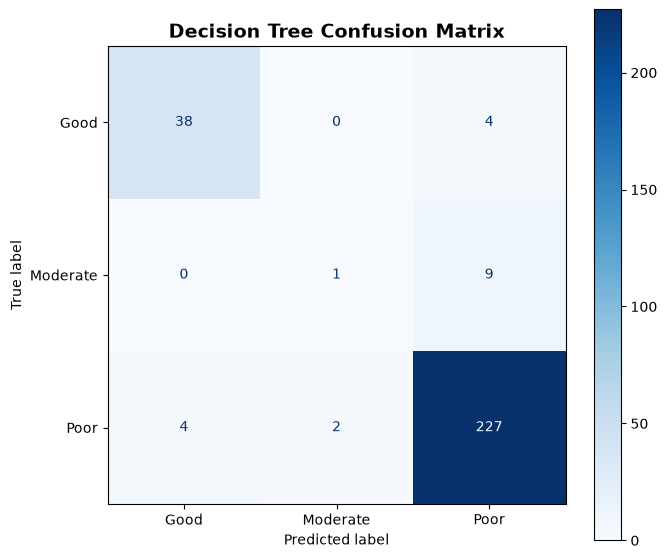

In [41]:
# --- 9. Confusion Matrix ---
labels = ['Good', 'Moderate', 'Poor']
cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=[f'Actual {l}' for l in labels], columns=[f'Pred {l}' for l in labels])

print('Confusion Matrix Table:')
print(cm_df)

# Visualizing Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Decision Tree Confusion Matrix', fontsize=14, fontweight='bold')
plt.grid(False)
plt.tight_layout()
plt.show()

## 10. Save Model & Scaler Artifacts
Save the trained Decision Tree model and feature scaler to `models/` directory for production deployment.

In [42]:
# --- 10. Save Model and Scaler ---
joblib.dump(model, 'models/decision_tree_model.joblib')
joblib.dump(scaler, 'models/decision_tree_scaler.joblib')
print('Saved models/decision_tree_model.joblib')
print('Saved models/decision_tree_scaler.joblib')

Saved models/decision_tree_model.joblib
Saved models/decision_tree_scaler.joblib
